In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
output_path = r'C:\Users\AGILA\OneDrive\Desktop\Projects\AMR_Resistance\data\amr_cleaned.csv'

In [17]:
# Load dataset using raw string or forward slashes
file_path = r'C:\Users\AGILA\OneDrive\Desktop\Projects\AMR_Resistance\data\amr_trends.csv'
df = pd.read_csv(file_path)

In [18]:
print("--- INITIAL SHAPE ---")
print(df.shape)

--- INITIAL SHAPE ---
(1286, 13)


In [32]:
print("--- DATA TYPES ---")
print(df.dtypes)

--- DATA TYPES ---
organism               object
antibiotic             object
year                    int64
susceptible_n           int64
tested_n                int64
susceptible_pct       float64
source_report_year      int64
source_table           object
source_url             object
extracted_date         object
reported_pct          float64
computed_pct          float64
flags                  object
dtype: object


In [33]:
print("--- INFORMATION SUMMARY---")
df.info()

--- INFORMATION SUMMARY---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   organism            1286 non-null   object 
 1   antibiotic          1286 non-null   object 
 2   year                1286 non-null   int64  
 3   susceptible_n       1286 non-null   int64  
 4   tested_n            1286 non-null   int64  
 5   susceptible_pct     1286 non-null   float64
 6   source_report_year  1286 non-null   int64  
 7   source_table        1286 non-null   object 
 8   source_url          1286 non-null   object 
 9   extracted_date      1286 non-null   object 
 10  reported_pct        1286 non-null   float64
 11  computed_pct        1286 non-null   float64
 12  flags               81 non-null     object 
dtypes: float64(3), int64(4), object(6)
memory usage: 130.7+ KB


In [34]:
print("\nDescriptive Statistics:\n", df.describe(include='all'))


Descriptive Statistics:
                       organism     antibiotic         year  susceptible_n  \
count                     1286           1286  1286.000000    1286.000000   
unique                       6             25          NaN            NaN   
top     Pseudomonas aeruginosa  ciprofloxacin          NaN            NaN   
freq                       231            105          NaN            NaN   
mean                       NaN            NaN  2020.041991    3223.991446   
std                        NaN            NaN     2.078561    2525.724242   
min                        NaN            NaN  2017.000000       0.000000   
25%                        NaN            NaN  2018.000000    1109.000000   
50%                        NaN            NaN  2020.000000    2627.500000   
75%                        NaN            NaN  2022.000000    4861.500000   
max                        NaN            NaN  2024.000000   11461.000000   

             tested_n  susceptible_pct  source_re

In [35]:
print("\n=== 2. MISSING VALUES QUANTIFICATION ===")
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().mean() * 100).round(2)
})
print(missing_table[missing_table['Missing Count'] > 0])


=== 2. MISSING VALUES QUANTIFICATION ===
       Missing Count  Missing Percentage (%)
flags           1205                    93.7


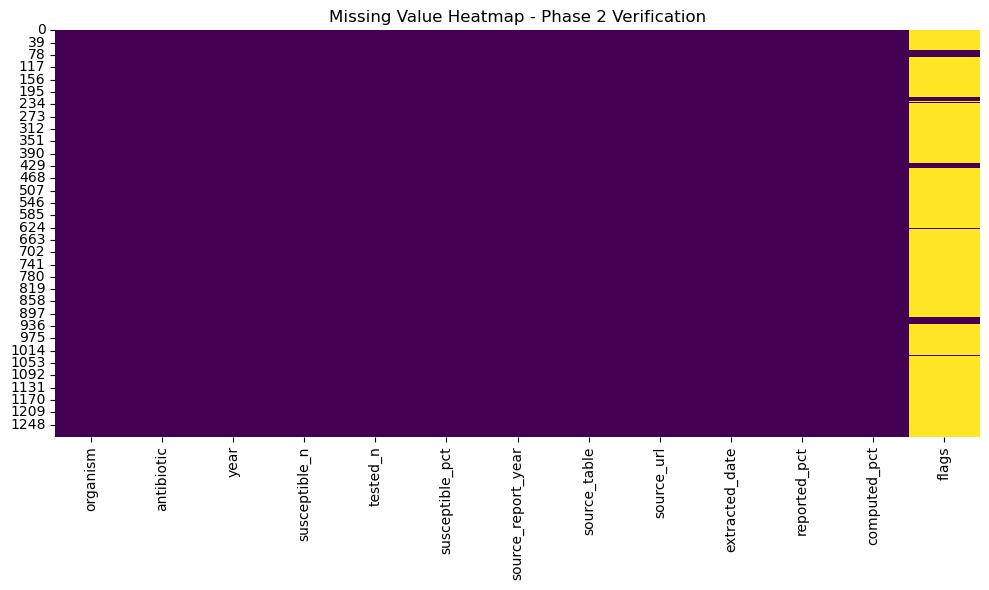

In [36]:
# Plot Missing Value Heatmap (Checklist requirement!)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap - Phase 2 Verification')
plt.tight_layout()
plt.savefig('reports/missing_values_heatmap.png', dpi=300)
plt.show()

In [24]:
# 1. Handle missing values
df['susceptible_pct'] = df['susceptible_pct'].fillna(df['computed_pct'])
df['susceptible_pct'] = df['susceptible_pct'].fillna(df['susceptible_pct'].median())

df['reported_pct'] = df['reported_pct'].fillna(df['susceptible_pct'])
df['computed_pct'] = df['computed_pct'].fillna(df['susceptible_pct'])

In [37]:
print("\n--- NEW MISSING VALUES ---")
print(df.isnull().sum())


--- NEW MISSING VALUES ---
organism                 0
antibiotic               0
year                     0
susceptible_n            0
tested_n                 0
susceptible_pct          0
source_report_year       0
source_table             0
source_url               0
extracted_date           0
reported_pct             0
computed_pct             0
flags                 1205
dtype: int64


In [38]:
print("\n=== 4. DUPLICATES REMOVED ===")
initial_len = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {initial_len - len(df)}")


=== 4. DUPLICATES REMOVED ===
Duplicates removed: 0


In [39]:
# Standardize string formatting for organisms and antibiotics (strip whitespace, lowercase)
df['organism'] = df['organism'].str.strip().str.title()
df['antibiotic'] = df['antibiotic'].str.strip().str.lower()
print("Unique organisms standardized:", df['organism'].unique())

Unique organisms standardized: ['Acinetobacter Baumannii' 'Escherichia Coli' 'Klebsiella Pneumoniae'
 'Mrsa' 'Pseudomonas Aeruginosa' 'Staphylococcus Aureus']


In [40]:
print("\n=== 6. DATE/YEAR PARSING AND SORTING ===")
# Parse extracted_date to datetime and sort dataframe by year and organism
df['extracted_date'] = pd.to_datetime(df['extracted_date'], errors='coerce')
df = df.sort_values(by=['year', 'organism']).reset_index(drop=True)
print("Data sorted by year and organism successfully. First 2 rows years:", df['year'].head(2).values)


=== 6. DATE/YEAR PARSING AND SORTING ===
Data sorted by year and organism successfully. First 2 rows years: [2017 2017]


In [42]:
# 2. Save cleaned file
df.to_csv(output_path, index=False)
print("\n--- SUCCESS ---")
print("Cleaned dataset successfully saved to 'data/amr_cleaned.csv'. Final shape:", df.shape)


--- SUCCESS ---
Cleaned dataset successfully saved to 'data/amr_cleaned.csv'. Final shape: (1286, 13)
